In [2]:
import pandas as pd
import numpy as np
np.set_printoptions(threshold=10000, linewidth=10000)
import sklearn
import matplotlib.pyplot as plt

In [3]:
'''write train data to csv, with output column'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/train/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #correct strings
    temp_df.T2_data = temp_df.T2_data.str.replace(",",".")
    temp_df.T2_data = temp_df.T2_data.str.replace(" ","").astype(float)#/1000
    #clip at zero
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    #add row with contents of current file
    array = np.vstack((array,temp_df.T2_data))

scaler = sklearn.preprocessing.MinMaxScaler()
array = scaler.fit_transform(array.T).T
train_df = pd.DataFrame(array)

#adding y column to df
train_df['y'] = pd.read_csv("../RMN/train/Output/OilSat.csv", sep="\t")['Oil_Sat']

#writing to csv file
# train_df.to_csv("./data_train.csv", sep="\t", index=False)
# train_df

In [4]:
'''write test data to csv'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/test/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #for test, no text correction, no clipping
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))
array = scaler.fit_transform(array.T).T
test_df = pd.DataFrame(array)
# test_df.to_csv("./data_test.csv", sep="\t", index=False)
# test_df

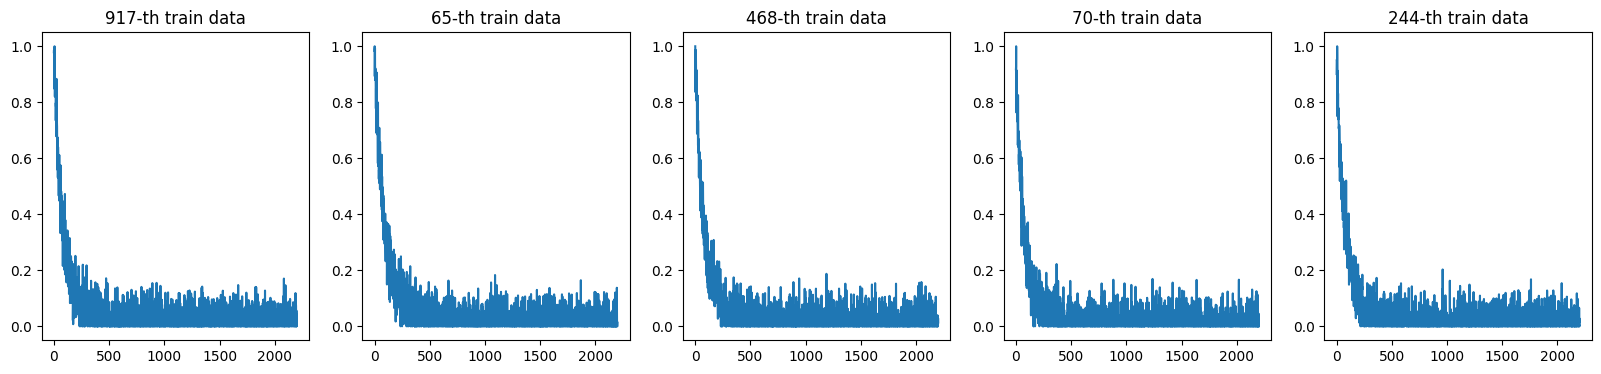

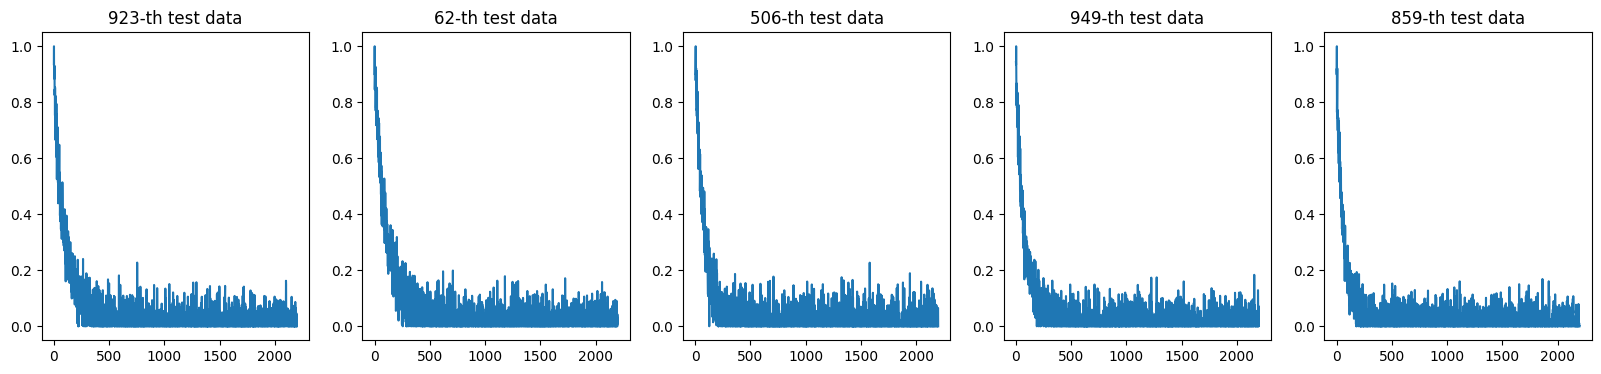

In [5]:
'''Plot graph of test and train after clip and normalization for comparison'''
fig, ax = plt.subplots(1,5, figsize=(20,4))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,4))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th test data")
plt.show();

Podemos implementar uma filtragem melhor com um autoencoder antes do smoothing:

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [8]:
X = torch.Tensor(np.vstack((train_df.iloc[:,:-1],test_df))).to(device)
y = X.to(device)

data_loader = DataLoader(TensorDataset(X, y), batch_size=256, shuffle=True)

In [9]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,X.shape[1]),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.189742
Epoch 20 | Train MSE: 0.003065
Epoch 40 | Train MSE: 0.002884
Epoch 60 | Train MSE: 0.002583
Epoch 80 | Train MSE: 0.002070
Epoch 100 | Train MSE: 0.001565
Epoch 120 | Train MSE: 0.001398
Epoch 140 | Train MSE: 0.001383
Epoch 160 | Train MSE: 0.001376
Epoch 180 | Train MSE: 0.001371
Epoch 200 | Train MSE: 0.001367
Epoch 220 | Train MSE: 0.001364
Epoch 240 | Train MSE: 0.001362
Epoch 260 | Train MSE: 0.001359
Epoch 280 | Train MSE: 0.001357
Epoch 300 | Train MSE: 0.001355
Epoch 320 | Train MSE: 0.001354
Epoch 340 | Train MSE: 0.001353
Epoch 360 | Train MSE: 0.001351
Epoch 380 | Train MSE: 0.001350
Epoch 400 | Train MSE: 0.001348
Epoch 420 | Train MSE: 0.001347
Epoch 440 | Train MSE: 0.001346
Epoch 460 | Train MSE: 0.001344
Epoch 480 | Train MSE: 0.001343


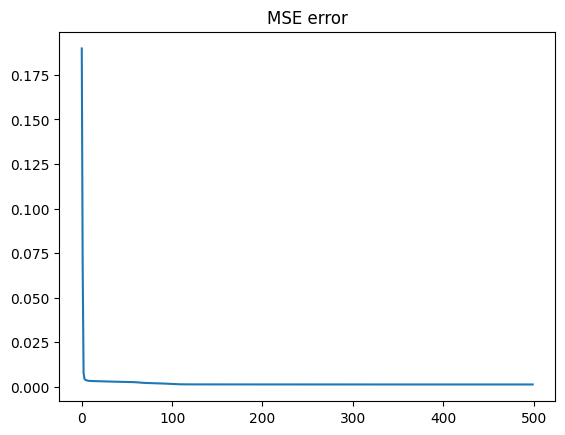

In [10]:
epochs = 500  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in data_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(data_loader.dataset)

    history.append(train_loss)

    if epoch%20==0: print(f"Epoch {epoch:002d} | Train MSE: {train_loss:.6f}")
plt.plot(history)
plt.title('MSE error')
plt.show()

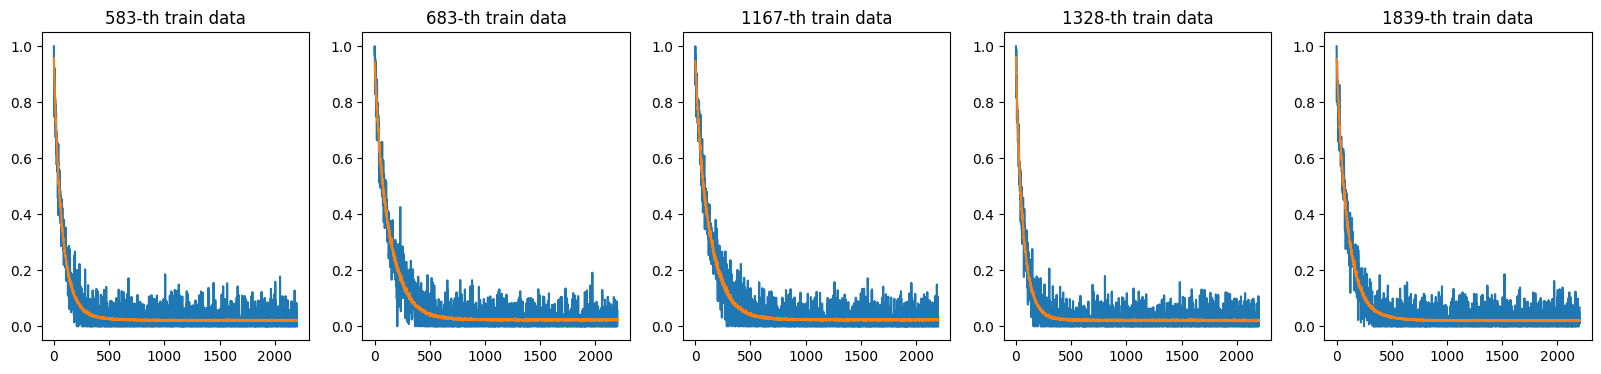

In [11]:
# Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(X).squeeze().detach().cpu().numpy()

fig, ax = plt.subplots(1,5, figsize=(20,4))
for i,j in enumerate(np.random.randint(1,len(X),5)):
    ax[i].plot(X.squeeze().detach().cpu().numpy()[j])
    ax[i].plot(y_pred[j])
    # ax[i].plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same")) #smoothed-out y_pred, edge-aware
    ax[i].set_title(f"{j}-th train data")
plt.show()

1839-th train data


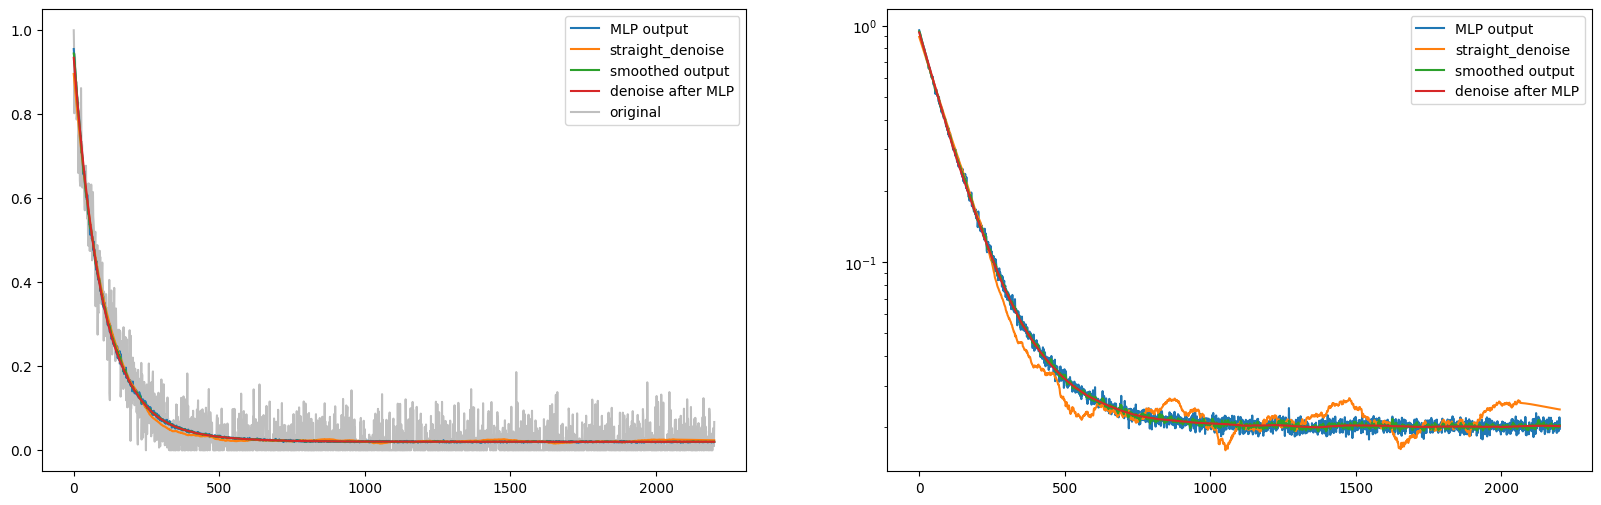

In [14]:
from scipy.signal import savgol_filter
window_length, polyorder = 271, 3

y_pred_savgolj = savgol_filter(y_pred[j], window_length, polyorder)
y_savgolj      = savgol_filter(X.squeeze().detach().cpu().numpy()[j], window_length, polyorder)

fig, (ax0,ax1) = plt.subplots(1,2, figsize=(20,6))

ax0.plot(y_pred[j], label="MLP output")
ax0.plot(y_savgolj, label="straight_denoise")
ax0.plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same"), label="smoothed output")
ax0.plot(y_pred_savgolj, label="denoise after MLP")
ax0.plot(X.squeeze().detach().cpu().numpy()[j], label="original", zorder=0, c='gray', alpha=.5)
# ax.yscale('log')
ax0.legend();

ax1.plot(y_pred[j], label="MLP output")
ax1.plot(y_savgolj, label="straight_denoise")
ax1.plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same"), label="smoothed output")
ax1.plot(y_pred_savgolj, label="denoise after MLP")
ax1.set_yscale('log')
ax1.legend();
print(f"{j}-th train data")
plt.show()

In [32]:
scaler = sklearn.preprocessing.MinMaxScaler()

array = y_pred
savgol_array = np.zeros((0,2201))
for i in range(len(y_pred)):
    row = savgol_filter(array[i], window_length, polyorder)
    savgol_array = np.vstack((savgol_array,row))
savgol_array = scaler.fit_transform(savgol_array.T).T

train_df_auto_savgol = pd.DataFrame(savgol_array[:1000,:700])
train_df_auto_savgol['y'] = train_df['y']
train_df_auto_savgol.to_csv("./data_train_post_n_auto_savgol.csv", sep="\t", index=False)

test_df_auto_savgol = pd.DataFrame(savgol_array[1000:,:700])
test_df_auto_savgol.to_csv("./data_test_post_n_auto_savgol.csv", sep="\t", index=False)

train_df_auto_savgol.shape, test_df_auto_savgol.shape

((1000, 701), (1000, 700))

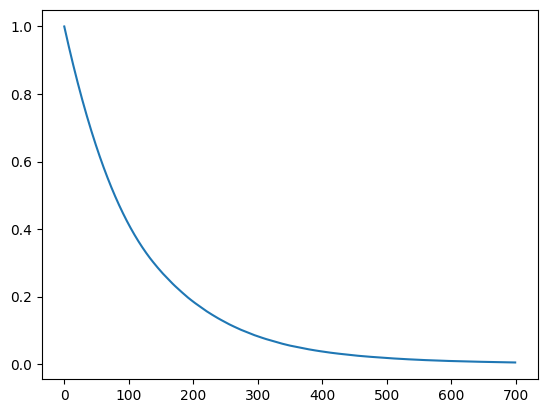

In [33]:
plt.plot(train_df_auto_savgol.iloc[45,:-1]);

In [34]:
print(train_df_auto_savgol.iloc[:,0].mean(), np.ptp(train_df_auto_savgol.iloc[:,0]))
print(test_df_auto_savgol.iloc[:,0].mean(),  np.ptp(test_df_auto_savgol.iloc[:,0]))

1.0 4.440892098500626e-16
1.0 4.440892098500626e-16
